<a href="https://colab.research.google.com/github/SattamAltwaim/EVE/blob/main/benchmarks/benchmark_eve_internals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVE Internals: Offspring Selection, Fitness & Direction Analysis

**ResNet-18 on CIFAR-10 -- 80 epochs**

Diagnostic experiments that expose the internal dynamics of the EVE optimizer:

1. **Offspring weights & fitness** -- which offspring (d1-d4) dominate and when
2. **Direction divergence** -- cosine similarity between offspring directions
3. **Strength signal** -- per-dimension evolutionary memory dynamics
4. **EVE vs Adam + random perturbations** -- does structured offspring design beat noise?

### Setup
Run first cell to clone repo and install. Designed for **Colab A100 (CUDA)**, falls back to MPS or CPU.

In [1]:
import os, sys, subprocess
if os.path.exists("/content"):
    subprocess.run(["git", "clone", "https://github.com/SattamAltwaim/EVE.git", "/content/EVE"],
                   capture_output=True, check=False)
    if "/content/EVE" not in sys.path:
        sys.path.insert(0, "/content/EVE")
else:
    parent = os.path.abspath(os.path.join(os.getcwd(), ".."))
    if os.path.exists(os.path.join(parent, "eve_optimizer")) and parent not in sys.path:
        sys.path.insert(0, parent)

from eve_optimizer import EVE
print("EVE imported successfully")

EVE imported successfully


In [2]:
import math, time, copy
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torch.func import functional_call, vmap
from scipy.stats import beta as beta_dist
from sklearn.metrics import f1_score

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

plt.rcParams.update({
    "figure.dpi": 130, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9,
})
OFFSPRING_LABELS = ["d1 (Adam)", "d2 (Slow Momentum)", "d3 (Complementary)", "d4 (Virtual SAM)"]
OFFSPRING_COLORS = ["#2563eb", "#16a34a", "#ea580c", "#9333ea"]

Device: cuda


In [3]:
# ── Data: CIFAR-10 ────────────────────────────────────────────────────────
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

full_train = torchvision.datasets.CIFAR10(root="./data", train=True,
                                          download=True, transform=transform_train)
test_set   = torchvision.datasets.CIFAR10(root="./data", train=False,
                                          download=True, transform=transform_test)

TRAIN_SUBSET = 5000
torch.manual_seed(42)
train_indices = torch.randperm(len(full_train))[:TRAIN_SUBSET].tolist()
train_set = Subset(full_train, train_indices)

BATCH_SIZE = 128
train_dl = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)
test_dl  = DataLoader(test_set, batch_size=512, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"Train subset: {len(train_set)}, Test: {len(test_set)}, "
      f"Batches/epoch: {len(train_dl)}, Batch size: {BATCH_SIZE}")

100%|██████████| 170M/170M [00:01<00:00, 104MB/s]


Train subset: 5000, Test: 10000, Batches/epoch: 39, Batch size: 128


In [4]:
# ── Model: ResNet-18 adapted for CIFAR-10 (32x32) ────────────────────────
def make_resnet18_cifar():
    """ResNet-18 with CIFAR-friendly stem (3x3 conv, no maxpool)."""
    model = torchvision.models.resnet18(num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(DEVICE)

def make_model():
    return make_resnet18_cifar()

_tmp = make_model()
print(f"ResNet-18 (CIFAR) params: {sum(p.numel() for p in _tmp.parameters()):,}")
del _tmp

ResNet-18 (CIFAR) params: 11,173,962


In [5]:
# ── Evaluation helper ─────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, dataloader, loss_fn=None):
    """Return (accuracy, val_loss, macro_f1)."""
    model.eval()
    loss_fn = loss_fn or nn.CrossEntropyLoss()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    total_loss = 0.0
    for xb, yb in dataloader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = model(xb)
        loss = loss_fn(out, yb)
        total_loss += loss.item() * yb.size(0)
        pred = out.argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
        all_preds.extend(pred.cpu().numpy().tolist())
        all_labels.extend(yb.cpu().numpy().tolist())
    acc = correct / total
    val_loss = total_loss / total
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return acc, val_loss, macro_f1

In [6]:
# ── Training loop for EVE with diagnostics ────────────────────────────────
EPOCHS = 50
RHO = 0.5

def train_eve_with_diagnostics(
    model, train_dl, test_dl, *,
    lr=1e-3, epochs=EPOCHS, K=4, rho=RHO,
    record_diagnostics=True,
):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = EVE(
        model.parameters(), lr=lr, K=K, rho=rho,
        record_diagnostics=record_diagnostics,
    )
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": [], "step_losses": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            optimizer.step(model=model, loss_fn=loss_fn, data=(xb, yb))
            epoch_loss += loss.item()
            n_batches += 1
            history["step_losses"].append(loss.item())

        history["train_loss"].append(epoch_loss / n_batches)
        acc, val_loss, macro_f1 = evaluate(model, test_dl, loss_fn=loss_fn)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(acc)
        history["val_macro_f1"].append(macro_f1)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs}  loss={history['train_loss'][-1]:.4f}  "
                  f"val_loss={val_loss:.4f}  val_acc={acc:.4f}  val_macro_f1={macro_f1:.4f}  "
                  f"beta_sel={optimizer.beta_sel:.3f}")

    return optimizer, history

---
## Experiment 1: Offspring Fitness & Selection Weight Dynamics

Track how the 4 offspring compete over 80 epochs of ResNet-18 training on CIFAR-10.

Key questions:
- Does d1 (Adam) always dominate, or do alternatives win?
- When do d3 (complementary) and d4 (virtual SAM) gain weight?
- How does beta_sel (temperature) adapt?

In [7]:
print("Training EVE (K=4) with diagnostics on ResNet-18 / CIFAR-10...")
torch.manual_seed(42)
model_diag = make_model()
opt_diag, hist_diag = train_eve_with_diagnostics(
    model_diag, train_dl, test_dl,
    lr=1e-3, epochs=EPOCHS, K=4, rho=RHO,
)
diag = opt_diag._diagnostics
print(f"\nCollected {len(diag)} diagnostic records over {EPOCHS} epochs.")
print(f"Final val accuracy: {hist_diag['val_acc'][-1]:.4f}  best val macro F1: {max(hist_diag['val_macro_f1']):.4f}")

Training EVE (K=4) with diagnostics on ResNet-18 / CIFAR-10...
  Epoch   1/50  loss=1.8888  val_loss=1.7301  val_acc=0.3815  val_macro_f1=0.3484  beta_sel=1.127
  Epoch  10/50  loss=0.8500  val_loss=1.4205  val_acc=0.5624  val_macro_f1=0.5491  beta_sel=4.360
  Epoch  20/50  loss=0.4642  val_loss=1.1791  val_acc=0.6663  val_macro_f1=0.6610  beta_sel=7.770
  Epoch  30/50  loss=0.2404  val_loss=1.1866  val_acc=0.7004  val_macro_f1=0.6998  beta_sel=12.672
  Epoch  40/50  loss=0.1680  val_loss=1.4822  val_acc=0.6903  val_macro_f1=0.6884  beta_sel=20.174
  Epoch  50/50  loss=0.1008  val_loss=1.6044  val_acc=0.6963  val_macro_f1=0.7001  beta_sel=32.697

Collected 1950 diagnostic records over 50 epochs.
Final val accuracy: 0.6963  best val macro F1: 0.7257


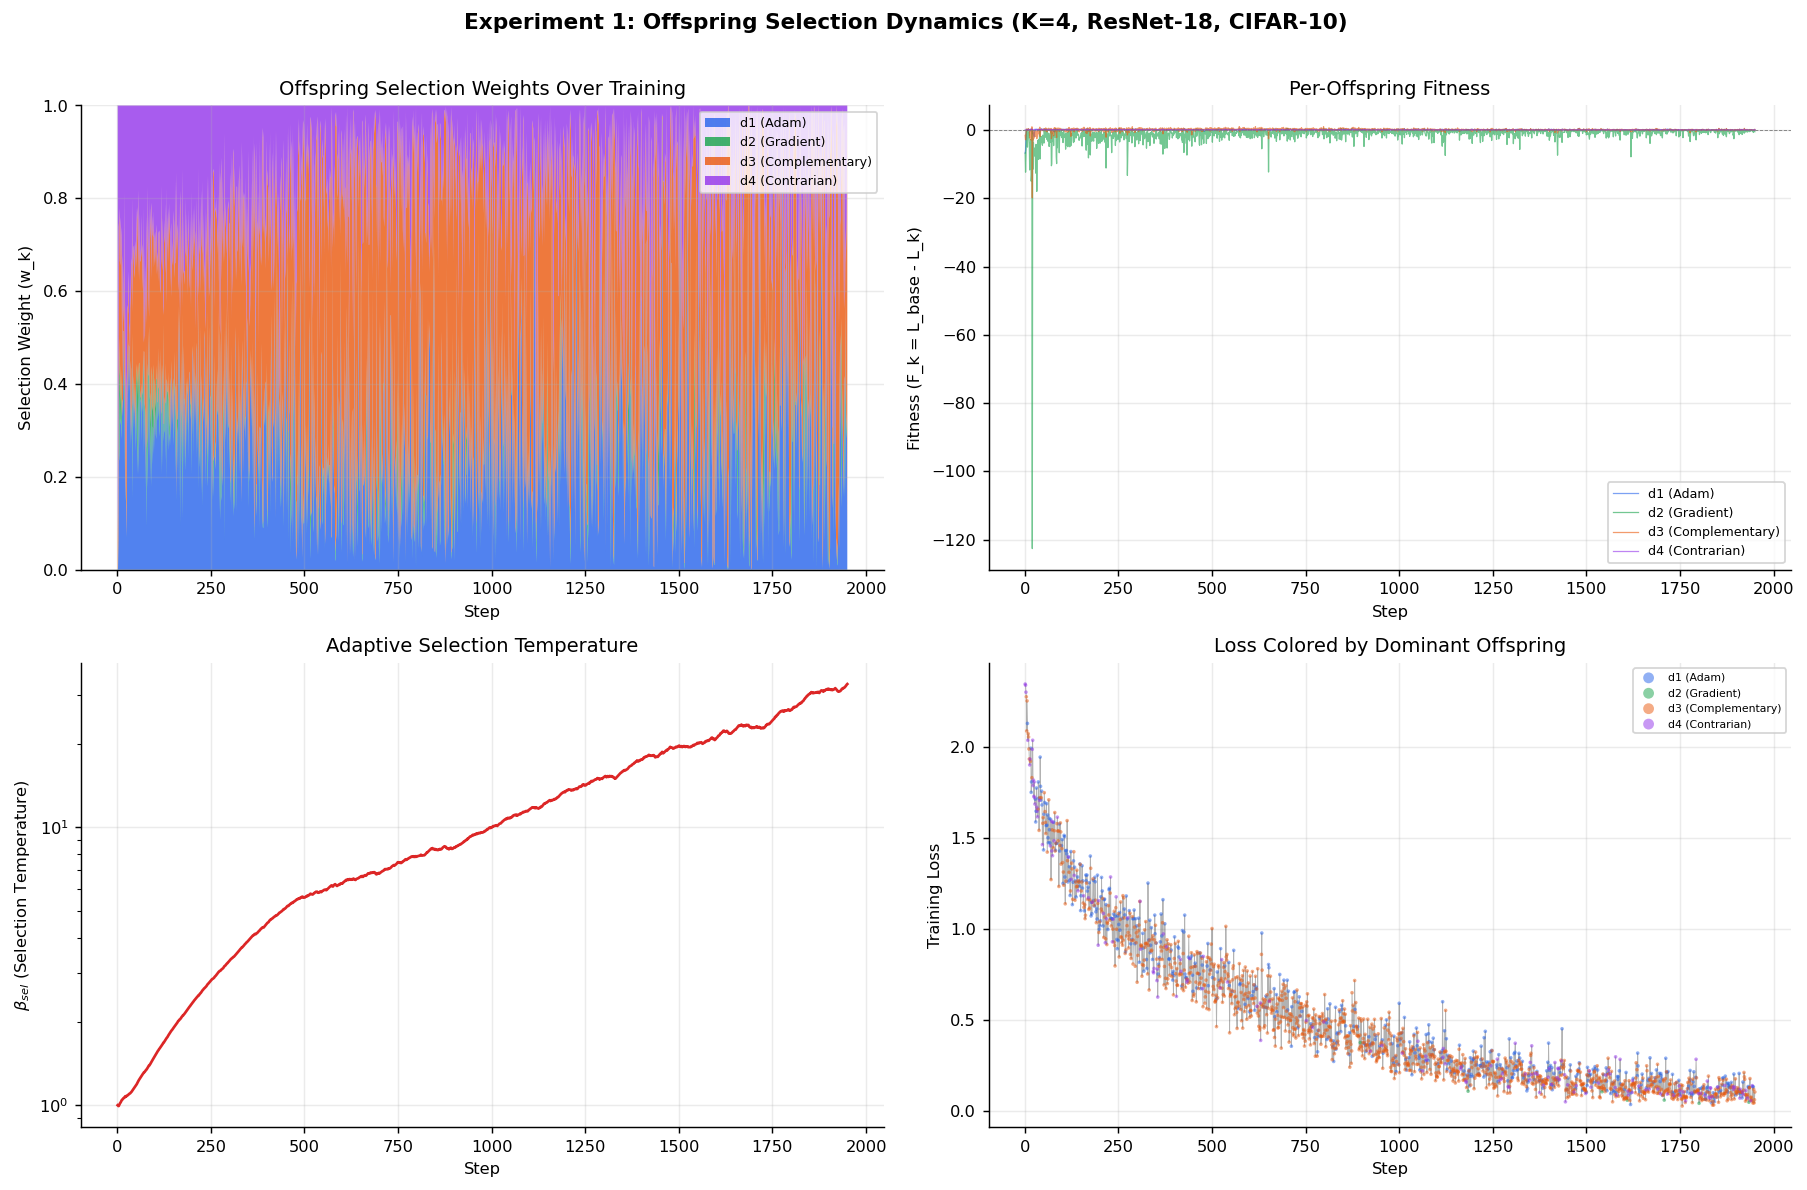

In [8]:
# ── Extract arrays ────────────────────────────────────────────────────────
steps     = np.array([d["step"] for d in diag])
w_arr     = np.array([d["weights"] for d in diag])       # (T, 4)
f_arr     = np.array([d["fitness"] for d in diag])       # (T, 4)
beta_arr  = np.array([d["beta_sel"] for d in diag])      # (T,)
loss_arr  = np.array([d["loss"] if d["loss"] is not None else np.nan for d in diag])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1a. Stacked area: selection weights
ax = axes[0, 0]
ax.stackplot(steps, w_arr.T, labels=OFFSPRING_LABELS, colors=OFFSPRING_COLORS, alpha=0.8)
ax.set_ylabel("Selection Weight (w_k)")
ax.set_xlabel("Step")
ax.set_title("Offspring Selection Weights Over Training")
ax.set_ylim(0, 1)
ax.legend(loc="upper right", fontsize=7)

# 1b. Fitness values
ax = axes[0, 1]
for k in range(4):
    ax.plot(steps, f_arr[:, k], label=OFFSPRING_LABELS[k],
            color=OFFSPRING_COLORS[k], alpha=0.6, linewidth=0.7)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_ylabel("Fitness (F_k = L_base - L_k)")
ax.set_xlabel("Step")
ax.set_title("Per-Offspring Fitness")
ax.legend(fontsize=7)

# 1c. beta_sel trajectory
ax = axes[1, 0]
ax.plot(steps, beta_arr, color="#dc2626", linewidth=1.5)
ax.set_ylabel(r"$\beta_{sel}$ (Selection Temperature)")
ax.set_xlabel("Step")
ax.set_title("Adaptive Selection Temperature")
ax.set_yscale("log")

# 1d. Training loss colored by dominant offspring
ax = axes[1, 1]
dominant = w_arr.argmax(axis=1)
valid_mask = ~np.isnan(loss_arr)
ax.plot(steps[valid_mask], loss_arr[valid_mask], color="black", linewidth=0.5, alpha=0.3)
for k in range(4):
    mask = (dominant == k) & valid_mask
    if mask.any():
        ax.scatter(steps[mask], loss_arr[mask], color=OFFSPRING_COLORS[k],
                   s=4, alpha=0.5, label=OFFSPRING_LABELS[k], zorder=3, edgecolors="none")
ax.set_ylabel("Training Loss")
ax.set_xlabel("Step")
ax.set_title("Loss Colored by Dominant Offspring")
ax.legend(fontsize=6, loc="upper right", markerscale=3)

fig.suptitle("Experiment 1: Offspring Selection Dynamics (K=4, ResNet-18, CIFAR-10)",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

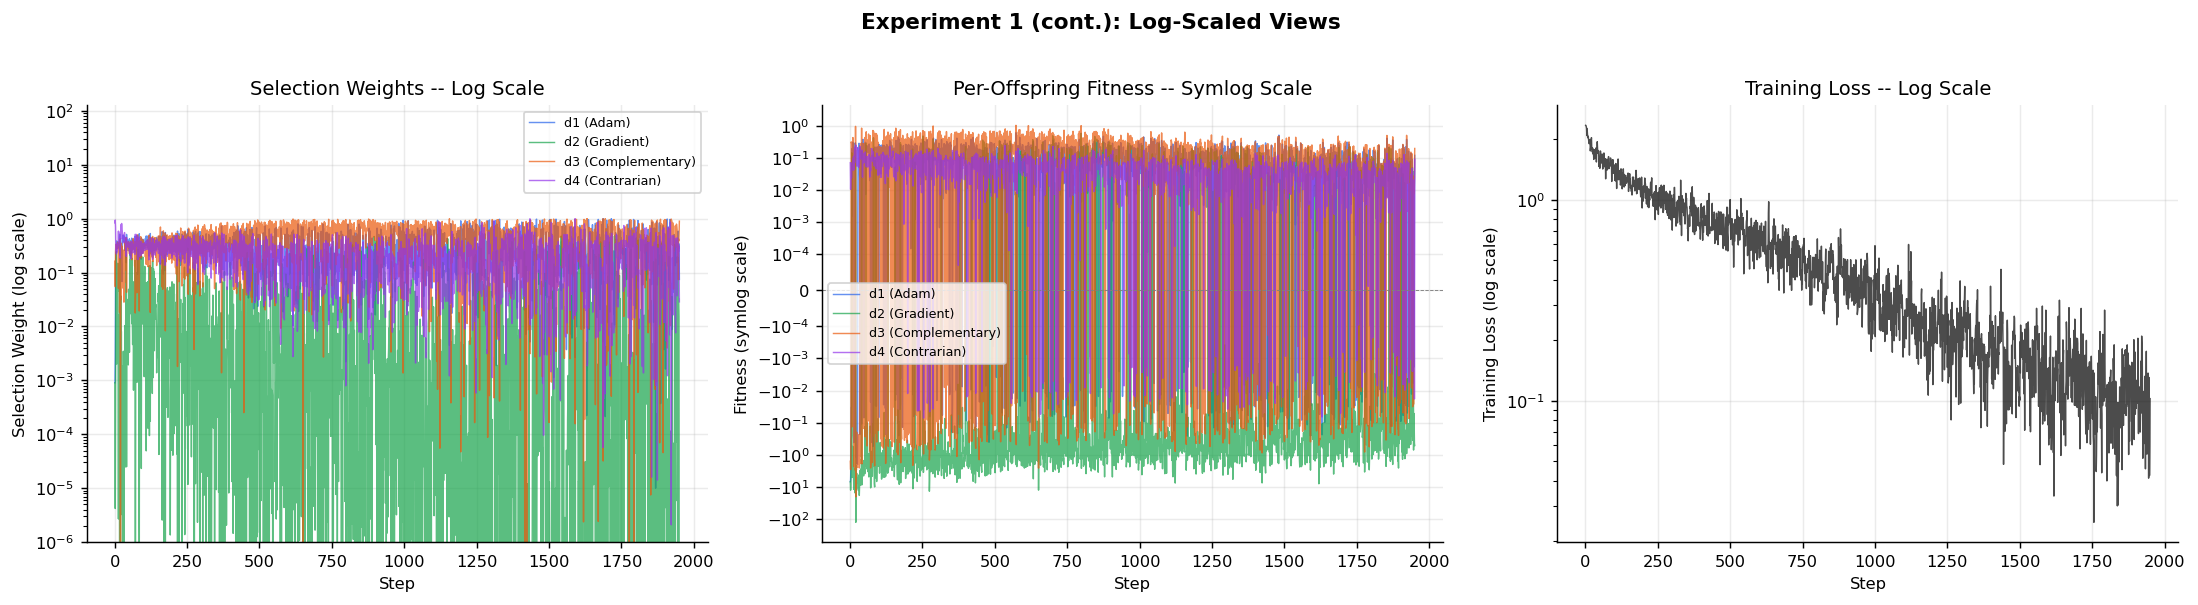

In [9]:
# ── Log-scaled views for fine detail ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 1e. Selection weights on log scale (reveals small contributions)
ax = axes[0]
for k in range(4):
    ax.plot(steps, w_arr[:, k], label=OFFSPRING_LABELS[k],
            color=OFFSPRING_COLORS[k], linewidth=0.8, alpha=0.7)
ax.set_yscale("log")
ax.set_ylabel("Selection Weight (log scale)")
ax.set_xlabel("Step")
ax.set_title("Selection Weights -- Log Scale")
ax.legend(fontsize=7)
ax.set_ylim(bottom=1e-6)

# 1f. Fitness on symlog scale (captures both positive and negative)
ax = axes[1]
for k in range(4):
    ax.plot(steps, f_arr[:, k], label=OFFSPRING_LABELS[k],
            color=OFFSPRING_COLORS[k], linewidth=0.8, alpha=0.7)
ax.set_yscale("symlog", linthresh=1e-4)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_ylabel("Fitness (symlog scale)")
ax.set_xlabel("Step")
ax.set_title("Per-Offspring Fitness -- Symlog Scale")
ax.legend(fontsize=7)

# 1g. Training loss on log scale
ax = axes[2]
valid = ~np.isnan(loss_arr)
ax.plot(steps[valid], loss_arr[valid], color="black", linewidth=0.8, alpha=0.7)
ax.set_yscale("log")
ax.set_ylabel("Training Loss (log scale)")
ax.set_xlabel("Step")
ax.set_title("Training Loss -- Log Scale")

fig.suptitle("Experiment 1 (cont.): Log-Scaled Views",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [10]:
print("=" * 65)
print("Offspring Dominance Summary")
print("=" * 65)
dominant = w_arr.argmax(axis=1)
for k in range(4):
    pct = (dominant == k).mean() * 100
    avg_w = w_arr[:, k].mean()
    avg_f = f_arr[:, k].mean()
    print(f"  {OFFSPRING_LABELS[k]:25s}  dominant {pct:5.1f}%  "
          f"avg_weight={avg_w:.4f}  avg_fitness={avg_f:.6f}")

# Per-phase breakdown (early / mid / late)
T = len(diag)
phases = [("Early (0-33%)", 0, T//3), ("Mid (33-66%)", T//3, 2*T//3), ("Late (66-100%)", 2*T//3, T)]
print(f"\n{'Phase':<20s}", end="")
for lbl in OFFSPRING_LABELS:
    print(f"  {lbl:>15s}", end="")
print()
print("-" * 85)
for phase_name, i0, i1 in phases:
    print(f"{phase_name:<20s}", end="")
    for k in range(4):
        print(f"  {w_arr[i0:i1, k].mean():15.4f}", end="")
    print()

print(f"\nFinal beta_sel: {beta_arr[-1]:.4f}")
print(f"Final val accuracy: {hist_diag['val_acc'][-1]:.4f}  Best val accuracy:  {max(hist_diag['val_acc']):.4f}")
print(f"Best val macro F1: {max(hist_diag['val_macro_f1']):.4f}")

Offspring Dominance Summary
  d1 (Adam)                  dominant  27.7%  avg_weight=0.2973  avg_fitness=0.082019
  d2 (Gradient)              dominant   0.4%  avg_weight=0.0267  avg_fitness=-1.143740
  d3 (Complementary)         dominant  63.3%  avg_weight=0.4723  avg_fitness=0.099835
  d4 (Contrarian)            dominant   8.6%  avg_weight=0.2036  avg_fitness=0.045157

Phase                       d1 (Adam)    d2 (Gradient)  d3 (Complementary)  d4 (Contrarian)
-------------------------------------------------------------------------------------
Early (0-33%)                  0.2999           0.0267           0.4173           0.2561
Mid (33-66%)                   0.2787           0.0227           0.5390           0.1596
Late (66-100%)                 0.3135           0.0306           0.4607           0.1952

Final beta_sel: 32.7948
Final val accuracy: 0.6963  Best val accuracy:  0.7289
Best val macro F1: 0.7257


---
## Experiment 2: Offspring Direction Divergence

How different are the 4 offspring directions from each other? If they are nearly parallel, EVE gains little from selection. If they diverge, selection is choosing between genuinely different strategies.

On ResNet-18 we expect more divergence than on a small MLP since the parameter space mixes conv, BN, and FC layers with very different curvature profiles.

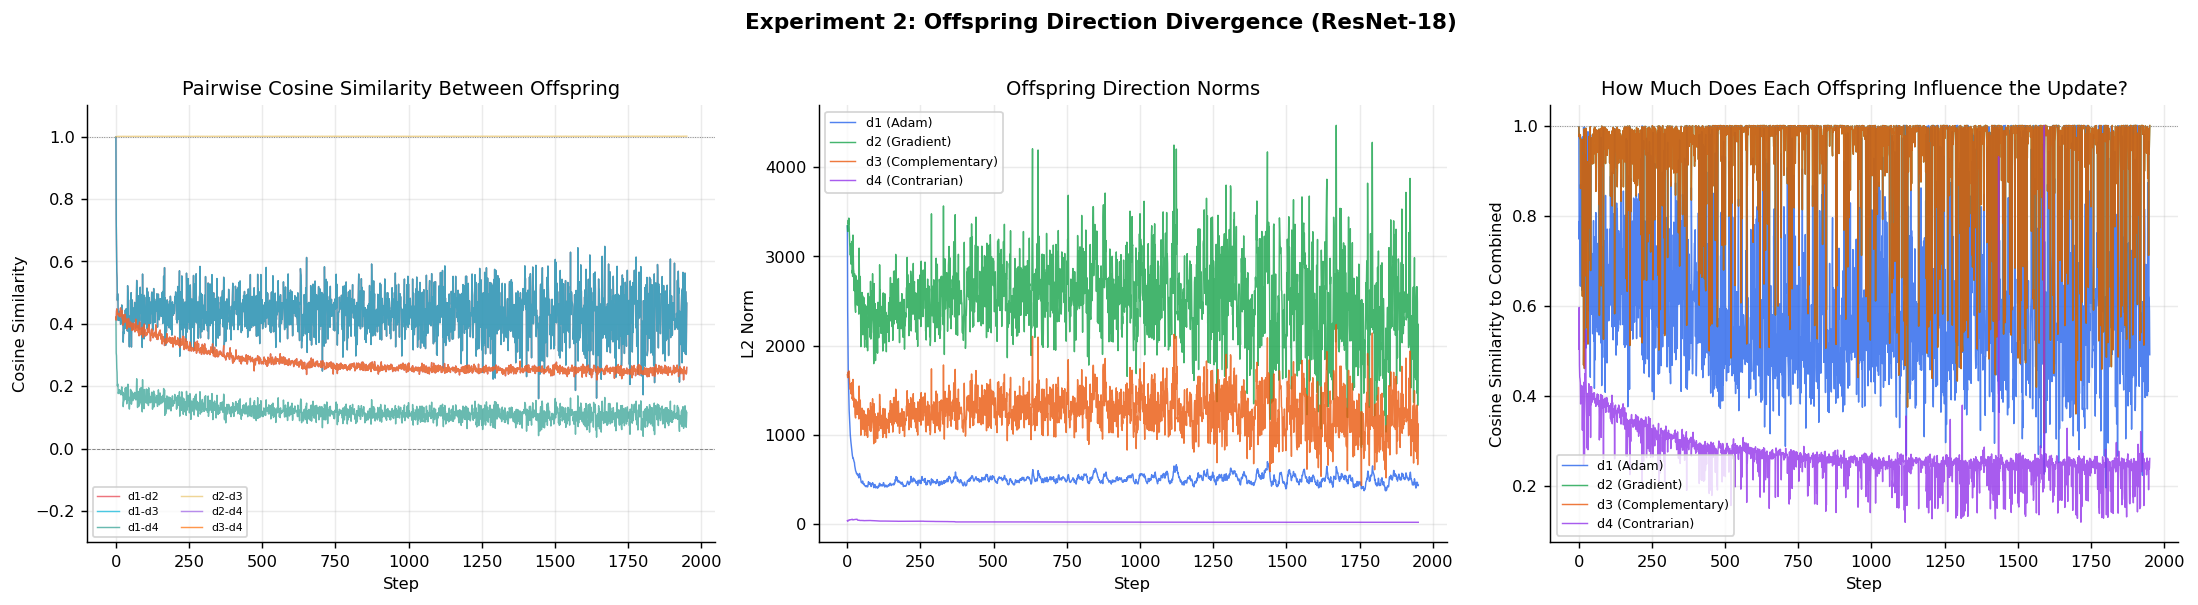

In [11]:
pair_keys = list(diag[0]["cos_pairs"].keys())
cos_arr = np.array([[d["cos_pairs"][k] for k in pair_keys] for d in diag])
norm_arr = np.array([d["dir_norms"] for d in diag])
cos_comb_arr = np.array([d["cos_to_combined"] for d in diag])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 2a. Pairwise cosine similarities
ax = axes[0]
pair_colors = ["#e63946", "#00b4d8", "#2a9d8f", "#e9c46a", "#9b5de5", "#ff6b00"]
for i, key in enumerate(pair_keys):
    ax.plot(steps, cos_arr[:, i], label=key, color=pair_colors[i % len(pair_colors)],
            linewidth=0.8, alpha=0.7)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.5)
ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.5)
ax.set_ylabel("Cosine Similarity")
ax.set_xlabel("Step")
ax.set_title("Pairwise Cosine Similarity Between Offspring")
ax.legend(fontsize=6, ncol=2)
ax.set_ylim(-0.3, 1.1)

# 2b. Direction norms
ax = axes[1]
for k in range(4):
    ax.plot(steps, norm_arr[:, k], label=OFFSPRING_LABELS[k],
            color=OFFSPRING_COLORS[k], linewidth=0.8, alpha=0.8)
ax.set_ylabel("L2 Norm")
ax.set_xlabel("Step")
ax.set_title("Offspring Direction Norms")
ax.legend(fontsize=7)

# 2c. Cosine to combined direction
ax = axes[2]
for k in range(4):
    ax.plot(steps, cos_comb_arr[:, k], label=OFFSPRING_LABELS[k],
            color=OFFSPRING_COLORS[k], linewidth=0.8, alpha=0.8)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.5)
ax.set_ylabel("Cosine Similarity to Combined")
ax.set_xlabel("Step")
ax.set_title("How Much Does Each Offspring Influence the Update?")
ax.legend(fontsize=7)

fig.suptitle("Experiment 2: Offspring Direction Divergence (ResNet-18)",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

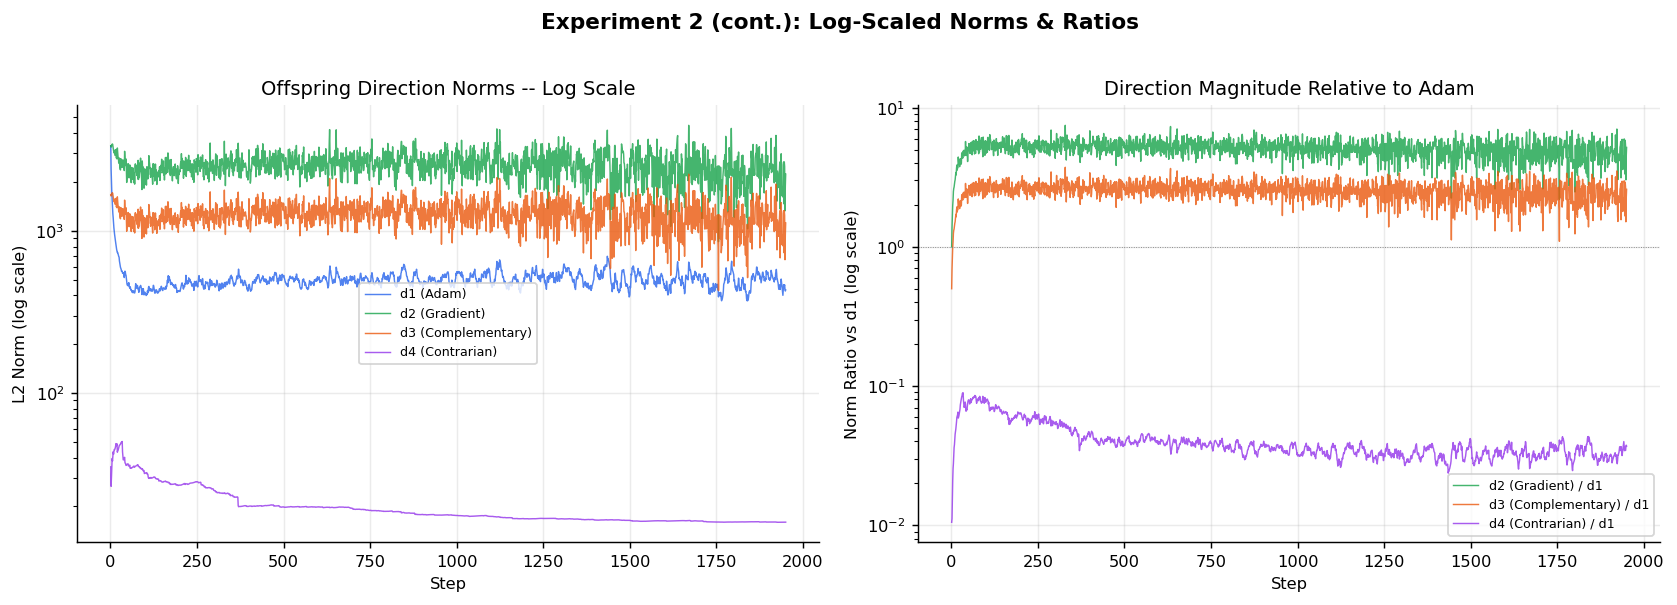

In [12]:
# ── Log-scaled direction norms ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 2d. Direction norms on log scale
ax = axes[0]
for k in range(4):
    ax.plot(steps, norm_arr[:, k], label=OFFSPRING_LABELS[k],
            color=OFFSPRING_COLORS[k], linewidth=0.8, alpha=0.8)
ax.set_yscale("log")
ax.set_ylabel("L2 Norm (log scale)")
ax.set_xlabel("Step")
ax.set_title("Offspring Direction Norms -- Log Scale")
ax.legend(fontsize=7)

# 2e. Norm ratios relative to d1 (Adam)
ax = axes[1]
for k in range(1, 4):
    ratio = norm_arr[:, k] / np.clip(norm_arr[:, 0], 1e-12, None)
    ax.plot(steps, ratio, label=f"{OFFSPRING_LABELS[k]} / d1",
            color=OFFSPRING_COLORS[k], linewidth=0.8, alpha=0.8)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.5)
ax.set_yscale("log")
ax.set_ylabel("Norm Ratio vs d1 (log scale)")
ax.set_xlabel("Step")
ax.set_title("Direction Magnitude Relative to Adam")
ax.legend(fontsize=7)

fig.suptitle("Experiment 2 (cont.): Log-Scaled Norms & Ratios",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [13]:
print("=" * 65)
print("Direction Divergence Summary")
print("=" * 65)
for i, key in enumerate(pair_keys):
    avg_cos = cos_arr[:, i].mean()
    min_cos = cos_arr[:, i].min()
    print(f"  cos({key:8s})  avg={avg_cos:+.4f}  min={min_cos:+.4f}")
print()
for k in range(4):
    avg_norm = norm_arr[:, k].mean()
    avg_cos_c = cos_comb_arr[:, k].mean()
    print(f"  {OFFSPRING_LABELS[k]:25s}  avg_norm={avg_norm:.4f}  "
          f"avg_cos_to_combined={avg_cos_c:+.4f}")

Direction Divergence Summary
  cos(d1-d2   )  avg=+0.4362  min=+0.1601
  cos(d1-d3   )  avg=+0.4362  min=+0.1600
  cos(d1-d4   )  avg=+0.1190  min=+0.0365
  cos(d2-d3   )  avg=+1.0012  min=+0.9998
  cos(d2-d4   )  avg=+0.2775  min=+0.2198
  cos(d3-d4   )  avg=+0.2775  min=+0.2198

  d1 (Adam)                  avg_norm=505.0697  avg_cos_to_combined=+0.6340
  d2 (Gradient)              avg_norm=2538.0088  avg_cos_to_combined=+0.9217
  d3 (Complementary)         avg_norm=1268.5301  avg_cos_to_combined=+0.9217
  d4 (Contrarian)            avg_norm=19.9231  avg_cos_to_combined=+0.2649


---
## Experiment 3: Strength Signal Dynamics

The strength signal `s` is EVE's evolutionary memory. It tracks per-dimension historical success:
- `s -> 1` where Adam is succeeding
- `s -> 0` where Adam is failing

The complementary offspring d3 multiplies a momentum-gradient blend by `(1 - s)`, amplifying signal on low-s (failing) dimensions.

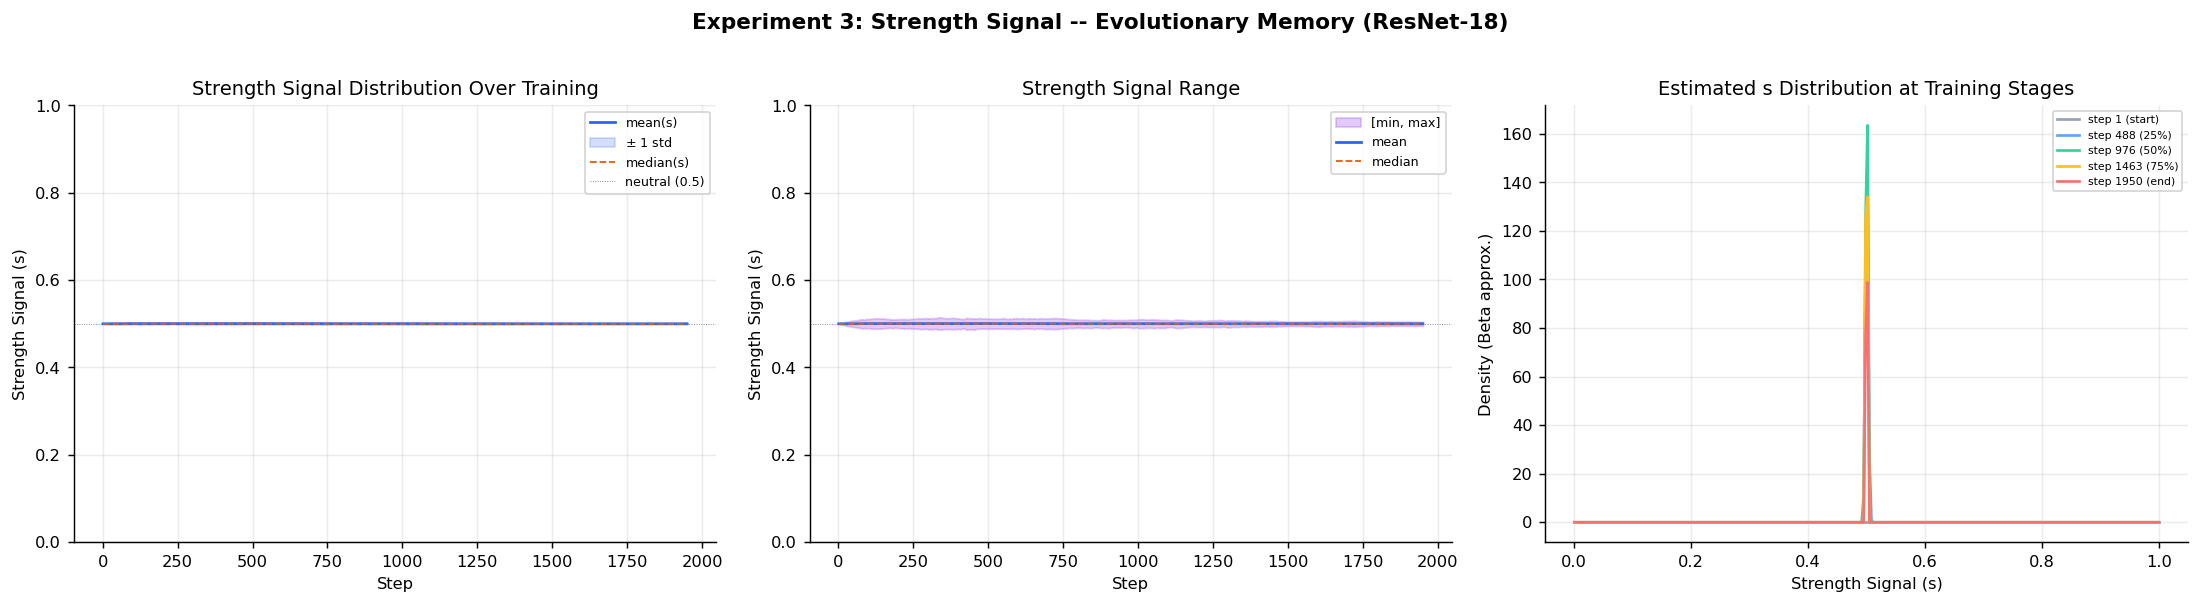

In [14]:
s_records = [d for d in diag if d["s_stats"]]
s_steps = np.array([d["step"] for d in s_records])
s_mean = np.array([d["s_stats"]["mean"] for d in s_records])
s_std  = np.array([d["s_stats"]["std"]  for d in s_records])
s_min  = np.array([d["s_stats"]["min"]  for d in s_records])
s_max  = np.array([d["s_stats"]["max"]  for d in s_records])
s_med  = np.array([d["s_stats"]["median"] for d in s_records])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 3a. Mean +/- std of strength signal
ax = axes[0]
ax.plot(s_steps, s_mean, color="#2563eb", linewidth=1.5, label="mean(s)")
ax.fill_between(s_steps, np.clip(s_mean - s_std, 0, 1),
                np.clip(s_mean + s_std, 0, 1),
                alpha=0.2, color="#2563eb", label=r"$\pm$ 1 std")
ax.plot(s_steps, s_med, color="#ea580c", linewidth=1, linestyle="--", label="median(s)")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.5, label="neutral (0.5)")
ax.set_ylabel("Strength Signal (s)")
ax.set_xlabel("Step")
ax.set_title("Strength Signal Distribution Over Training")
ax.set_ylim(0, 1)
ax.legend(fontsize=7)

# 3b. Min / Max envelope
ax = axes[1]
ax.fill_between(s_steps, s_min, s_max, alpha=0.25, color="#9333ea", label="[min, max]")
ax.plot(s_steps, s_mean, color="#2563eb", linewidth=1.5, label="mean")
ax.plot(s_steps, s_med, color="#ea580c", linewidth=1, linestyle="--", label="median")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.5)
ax.set_ylabel("Strength Signal (s)")
ax.set_xlabel("Step")
ax.set_title("Strength Signal Range")
ax.set_ylim(0, 1)
ax.legend(fontsize=7)

# 3c. Estimated s distribution at different training stages
ax = axes[2]
n_recs = len(s_records)
checkpoints = [0, n_recs//4, n_recs//2, 3*n_recs//4, n_recs-1]
stage_colors = ["#94a3b8", "#60a5fa", "#34d399", "#fbbf24", "#f87171"]
stage_labels = ["start", "25%", "50%", "75%", "end"]

x_range = np.linspace(0.001, 0.999, 300)
for idx, col, lbl in zip(checkpoints, stage_colors, stage_labels):
    rec = s_records[idx]
    mu = rec["s_stats"]["mean"]
    sigma = rec["s_stats"]["std"]
    sigma_sq = max(sigma**2, 1e-10)
    if mu * (1 - mu) > sigma_sq and 0.01 < mu < 0.99:
        alpha_p = max(mu * (mu * (1 - mu) / sigma_sq - 1), 0.2)
        beta_p = max((1 - mu) * (mu * (1 - mu) / sigma_sq - 1), 0.2)
        pdf = beta_dist.pdf(x_range, alpha_p, beta_p)
        ax.plot(x_range, pdf, color=col, linewidth=1.5,
                label=f"step {rec['step']} ({lbl})")
    else:
        ax.axvline(mu, color=col, linewidth=1.5, linestyle="--",
                   label=f"step {rec['step']} ({lbl}), mean={mu:.3f}")

ax.set_xlabel("Strength Signal (s)")
ax.set_ylabel("Density (Beta approx.)")
ax.set_title("Estimated s Distribution at Training Stages")
ax.legend(fontsize=6)

fig.suptitle("Experiment 3: Strength Signal -- Evolutionary Memory (ResNet-18)",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

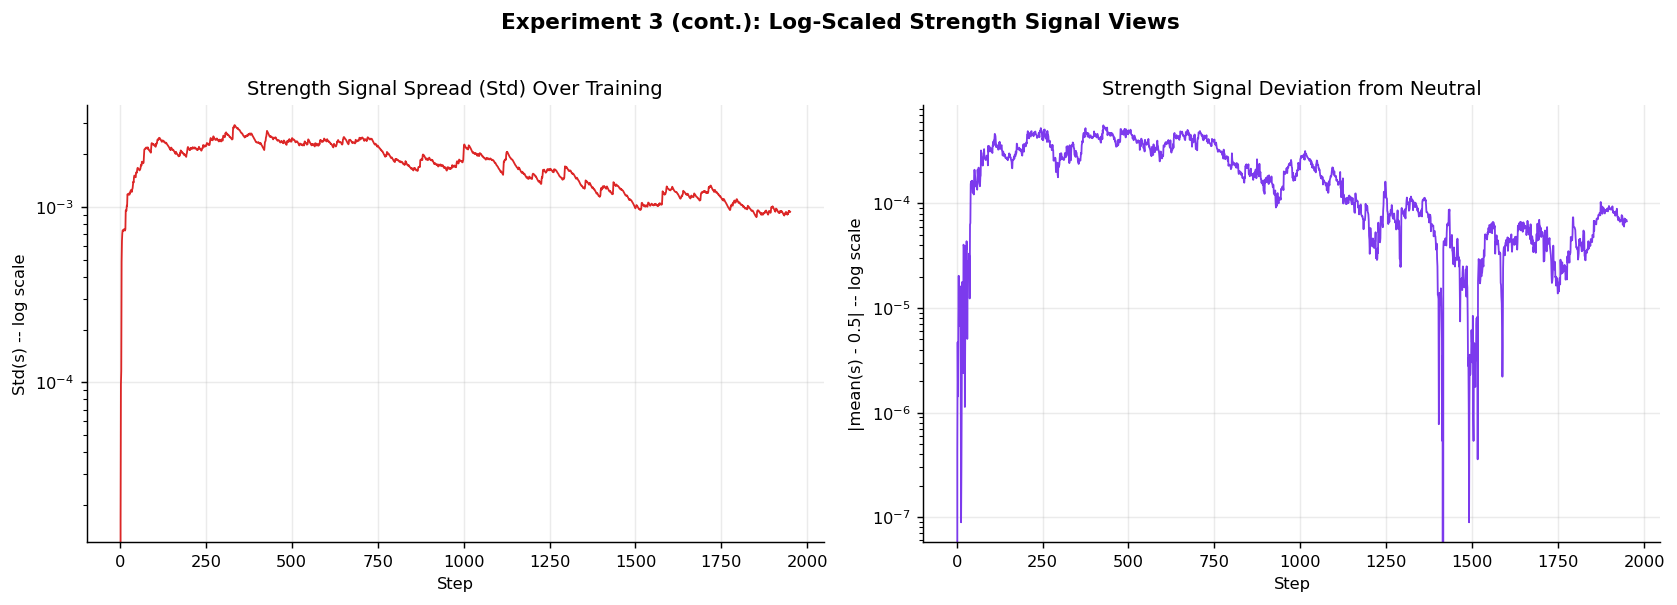

In [15]:
# ── Log-scaled std of strength signal ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 3d. Std(s) on log scale
ax = axes[0]
ax.plot(s_steps, s_std, color="#dc2626", linewidth=1)
ax.set_yscale("log")
ax.set_ylabel("Std(s) -- log scale")
ax.set_xlabel("Step")
ax.set_title("Strength Signal Spread (Std) Over Training")

# 3e. Deviation from neutral: |mean(s) - 0.5| on log scale
ax = axes[1]
dev = np.abs(s_mean - 0.5)
ax.plot(s_steps, dev, color="#7c3aed", linewidth=1)
ax.set_yscale("log")
ax.set_ylabel("|mean(s) - 0.5| -- log scale")
ax.set_xlabel("Step")
ax.set_title("Strength Signal Deviation from Neutral")

fig.suptitle("Experiment 3 (cont.): Log-Scaled Strength Signal Views",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [16]:
print("=" * 65)
print("Strength Signal Summary")
print("=" * 65)
first_s = s_records[0]["s_stats"]
last_s  = s_records[-1]["s_stats"]
print(f"  Initial: mean={first_s['mean']:.4f}  std={first_s['std']:.4f}  "
      f"[{first_s['min']:.4f}, {first_s['max']:.4f}]")
print(f"  Final:   mean={last_s['mean']:.4f}  std={last_s['std']:.4f}  "
      f"[{last_s['min']:.4f}, {last_s['max']:.4f}]")
print()
if last_s["mean"] > 0.6:
    print("  -> s > 0.5 on average: Adam directions mostly succeeding.")
    print("     d3 (complementary) focuses on the minority of failing dimensions.")
elif last_s["mean"] < 0.4:
    print("  -> s < 0.5 on average: Adam is struggling on many dimensions.")
    print("     d3 (complementary) is broadly active with substantial correction.")
else:
    print("  -> s near 0.5: mixed signal -- some dimensions succeeding, some failing.")
    print("     d3 provides balanced complementary exploration.")

Strength Signal Summary
  Initial: mean=0.5000  std=0.0000  [0.5000, 0.5000]
  Final:   mean=0.5001  std=0.0009  [0.4953, 0.5046]

  -> s near 0.5: mixed signal -- some dimensions succeeding, some failing.
     d3 provides balanced complementary exploration.


---
## Experiment 4: EVE vs Adam + Random Perturbations

Does EVE's structured offspring design (Adam, Slow Momentum, Complementary, Virtual SAM) actually beat simply adding random noise to the Adam direction and selecting the best?

We implement **NoisyAdamW**: same probe-and-select mechanism as EVE, but offspring = Adam direction + Gaussian noise. This isolates the value of intelligent offspring construction from the selection mechanism itself.

In [17]:
class NoisyAdamW(torch.optim.Optimizer):
    """AdamW with K random perturbations + probe-based selection.

    Same selection mechanism as EVE but offspring = Adam_dir + N(0, sigma^2).
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 weight_decay=0.01, K=4, sigma=0.1):
        defaults = dict(lr=lr, betas=betas, eps=eps,
                        weight_decay=weight_decay, K=K, sigma=sigma)
        super().__init__(params, defaults)
        self._step_count = 0
        self._history = {"weights_entropy": []}

    def step(self, closure=None, *, model=None, loss_fn=None, data=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        self._step_count += 1
        K = self.defaults["K"]
        sigma = self.defaults["sigma"]

        offspring_map, params_with_grad, ptr_to_lr = {}, [], {}

        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            eps = group["eps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["m"] = torch.zeros_like(p)
                    state["v"] = torch.zeros_like(p)
                state["step"] += 1
                m, v = state["m"], state["v"]
                m.mul_(beta1).add_(p.grad, alpha=1.0 - beta1)
                v.mul_(beta2).addcmul_(p.grad, p.grad, value=1.0 - beta2)
                m_hat = m / (1.0 - beta1 ** state["step"])
                denom = (v / (1.0 - beta2 ** state["step"])).sqrt() + eps

                adam_dir = m_hat.neg() / denom
                scale = adam_dir.norm().item() * sigma

                dirs = [adam_dir]
                for _ in range(K - 1):
                    dirs.append(adam_dir + torch.randn_like(adam_dir) * scale)
                offspring_map[p.data_ptr()] = torch.stack(dirs)
                ptr_to_lr[p.data_ptr()] = group["lr"]
                params_with_grad.append((group, p))

        if model is None or loss_fn is None or data is None:
            for group, p in params_with_grad:
                adam_dir = offspring_map[p.data_ptr()][0]
                lr, wd = group["lr"], group["weight_decay"]
                if wd != 0.0:
                    p.data.mul_(1.0 - lr * wd)
                p.data.add_(adam_dir, alpha=lr)
            return loss

        inp, tgt = data
        is_tuple = isinstance(inp, (tuple, list))
        batch_len = len(inp[0]) if is_tuple else len(inp)
        probe_size = max(1, batch_len // K)
        probe_inp = tuple(x[:probe_size] for x in inp) if is_tuple else inp[:probe_size]
        probe_tgt = tgt[:probe_size]
        fwd_inp = tuple(probe_inp) if is_tuple else (probe_inp,)

        stacked = {}
        for name, param in model.named_parameters():
            ptr = param.data_ptr()
            if ptr in offspring_map:
                stacked[name] = param.data.unsqueeze(0) + ptr_to_lr[ptr] * offspring_map[ptr]
            else:
                stacked[name] = param.data.unsqueeze(0).expand(K, *param.shape)

        was_training = model.training
        model.eval()

        def _probe(params):
            return loss_fn(functional_call(model, params, fwd_inp), probe_tgt)

        with torch.no_grad():
            plain_inp = probe_inp[0] if (is_tuple and len(probe_inp) == 1) else probe_inp
            L_base = loss_fn(model(plain_inp), probe_tgt)
            losses = torch.stack([
                _probe({n: stacked[n][k] for n in stacked}) for k in range(K)
            ])
        model.train(was_training)

        fitness = L_base - losses
        weights = torch.softmax(fitness, dim=0)

        log_w = torch.log(weights.clamp(min=1e-30))
        self._history["weights_entropy"].append(-(weights * log_w).sum().item())

        for group, p in params_with_grad:
            combined = torch.einsum("k...,k->...", offspring_map[p.data_ptr()], weights)
            lr, wd = group["lr"], group["weight_decay"]
            with torch.no_grad():
                if wd != 0.0:
                    p.data.mul_(1.0 - lr * wd)
                p.data.add_(combined, alpha=lr)
        return loss

In [18]:
def train_generic(make_opt_fn, train_dl, test_dl, *,
                  epochs=EPOCHS, use_eve_api=False, label=""):
    """Generic training loop; returns (optimizer, history)."""
    torch.manual_seed(42)
    model = make_model()
    loss_fn = nn.CrossEntropyLoss()
    optimizer = make_opt_fn(model.parameters())
    hist = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": [], "step_losses": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, n = 0.0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            if use_eve_api:
                optimizer.step(model=model, loss_fn=loss_fn, data=(xb, yb))
            else:
                optimizer.step()
            epoch_loss += loss.item()
            n += 1
            hist["step_losses"].append(loss.item())
        hist["train_loss"].append(epoch_loss / n)
        acc, val_loss, macro_f1 = evaluate(model, test_dl, loss_fn=loss_fn)
        hist["val_loss"].append(val_loss)
        hist["val_acc"].append(acc)
        hist["val_macro_f1"].append(macro_f1)
        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  [{label}] Epoch {epoch+1:3d}/{epochs}  "
                  f"loss={hist['train_loss'][-1]:.4f}  val_loss={val_loss:.4f}  "
                  f"val_acc={acc:.4f}  val_macro_f1={macro_f1:.4f}")

    return optimizer, hist

In [19]:
results = {}

print("=" * 50)
print("Training AdamW baseline...")
print("=" * 50)
_, results["AdamW"] = train_generic(
    lambda p: torch.optim.AdamW(p, lr=1e-3),
    train_dl, test_dl, epochs=EPOCHS, label="AdamW",
)

print()
print("=" * 50)
print("Training NoisyAdamW (Adam + random perturbations, K=4)...")
print("=" * 50)
opt_noisy, results["NoisyAdamW"] = train_generic(
    lambda p: NoisyAdamW(p, lr=1e-3, K=4, sigma=0.1),
    train_dl, test_dl, epochs=EPOCHS, use_eve_api=True, label="NoisyAdamW",
)

print()
print("=" * 50)
print(f"Training EVE (K=4, rho={RHO})...")
print("=" * 50)
opt_eve2, results["EVE"] = train_generic(
    lambda p: EVE(p, lr=1e-3, K=4, rho=RHO, record_diagnostics=True),
    train_dl, test_dl, epochs=EPOCHS, use_eve_api=True, label="EVE",
)

Training AdamW baseline...
  [AdamW] Epoch   1/50  loss=1.9207  val_loss=1.7544  val_acc=0.3693  val_macro_f1=0.3525
  [AdamW] Epoch  20/50  loss=0.5380  val_loss=0.9675  val_acc=0.6950  val_macro_f1=0.6939
  [AdamW] Epoch  40/50  loss=0.1546  val_loss=1.2313  val_acc=0.7232  val_macro_f1=0.7211

Training NoisyAdamW (Adam + random perturbations, K=4)...
  [NoisyAdamW] Epoch   1/50  loss=1.9244  val_loss=2.1085  val_acc=0.2981  val_macro_f1=0.2498
  [NoisyAdamW] Epoch  20/50  loss=0.6625  val_loss=1.0161  val_acc=0.6652  val_macro_f1=0.6710
  [NoisyAdamW] Epoch  40/50  loss=0.3048  val_loss=1.1084  val_acc=0.7141  val_macro_f1=0.7130

Training EVE (K=4, rho=0.5)...
  [EVE] Epoch   1/50  loss=1.8952  val_loss=1.8019  val_acc=0.3745  val_macro_f1=0.3317
  [EVE] Epoch  20/50  loss=0.4693  val_loss=1.1621  val_acc=0.6695  val_macro_f1=0.6655
  [EVE] Epoch  40/50  loss=0.1393  val_loss=1.2214  val_acc=0.7189  val_macro_f1=0.7205


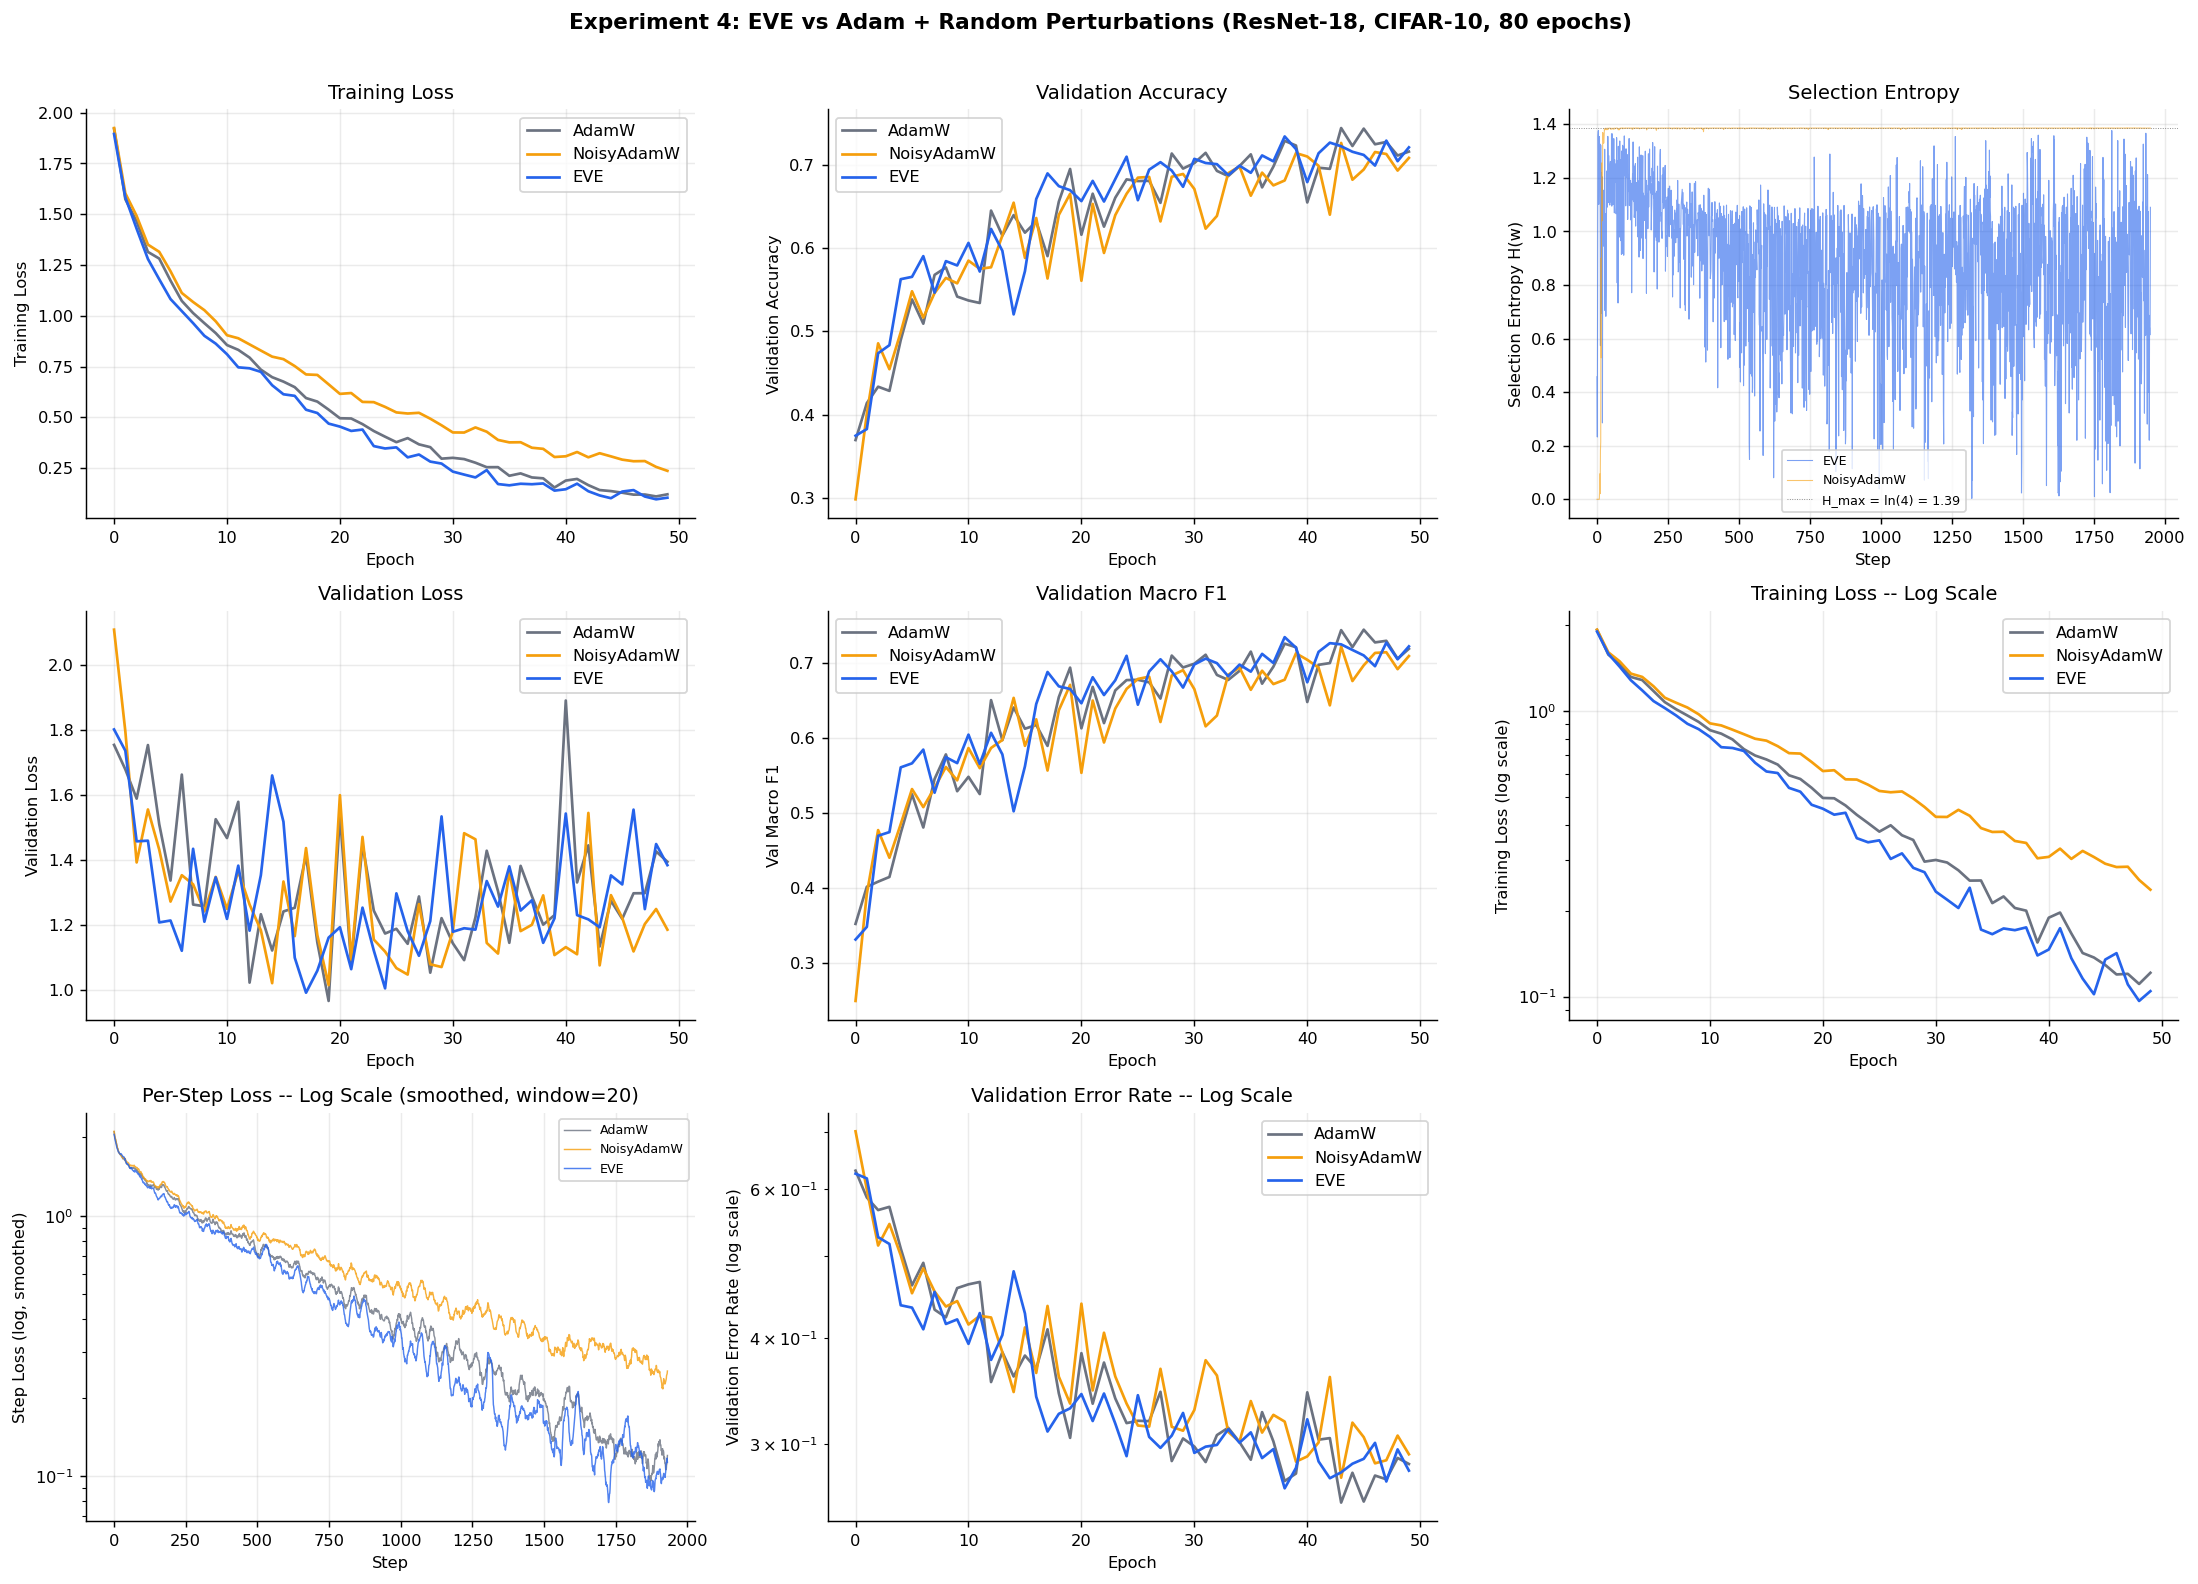

In [20]:
opt_colors = {"AdamW": "#6b7280", "NoisyAdamW": "#f59e0b", "EVE": "#2563eb"}

fig, axes = plt.subplots(3, 3, figsize=(17, 12))

# Row 1: linear scale
# 4a. Training loss per epoch
ax = axes[0, 0]
for name in ["AdamW", "NoisyAdamW", "EVE"]:
    ax.plot(results[name]["train_loss"], label=name,
            color=opt_colors[name], linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Training Loss")
ax.legend()

# 4b. Validation accuracy
ax = axes[0, 1]
for name in ["AdamW", "NoisyAdamW", "EVE"]:
    ax.plot(results[name]["val_acc"], label=name,
            color=opt_colors[name], linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy")
ax.legend()

# 4c. Selection entropy
ax = axes[0, 2]
eve_diag2 = opt_eve2._diagnostics
eve_entropy = []
for d in eve_diag2:
    w = np.array(d["weights"])
    eve_entropy.append(-np.sum(w * np.log(np.clip(w, 1e-30, None))))
noisy_entropy = opt_noisy._history["weights_entropy"]
max_ent = np.log(4)

ax.plot(eve_entropy, label="EVE", color=opt_colors["EVE"],
        linewidth=0.6, alpha=0.6)
ax.plot(noisy_entropy, label="NoisyAdamW", color=opt_colors["NoisyAdamW"],
        linewidth=0.6, alpha=0.6)
ax.axhline(max_ent, color="gray", linestyle=":", linewidth=0.5,
           label=f"H_max = ln(4) = {max_ent:.2f}")
ax.set_xlabel("Step")
ax.set_ylabel("Selection Entropy H(w)")
ax.set_title("Selection Entropy")
ax.legend(fontsize=7)

# Row 2: val loss, val macro F1
# 4d. Validation loss
ax = axes[1, 0]
for name in ["AdamW", "NoisyAdamW", "EVE"]:
    ax.plot(results[name]["val_loss"], label=name,
            color=opt_colors[name], linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss")
ax.legend()

# 4e. Validation macro F1
ax = axes[1, 1]
for name in ["AdamW", "NoisyAdamW", "EVE"]:
    ax.plot(results[name]["val_macro_f1"], label=name,
            color=opt_colors[name], linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Macro F1")
ax.set_title("Validation Macro F1")
ax.legend()

# 4f. Training loss -- log scale
ax = axes[1, 2]
for name in ["AdamW", "NoisyAdamW", "EVE"]:
    ax.plot(results[name]["train_loss"], label=name,
            color=opt_colors[name], linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss (log scale)")
ax.set_title("Training Loss -- Log Scale")
ax.legend()

# Row 3: log-scaled versions
# 4g. Per-step loss -- log scale (smoothed)
ax = axes[2, 0]
window = 20
for name in ["AdamW", "NoisyAdamW", "EVE"]:
    raw = np.array(results[name]["step_losses"])
    if len(raw) > window:
        smoothed = np.convolve(raw, np.ones(window)/window, mode="valid")
        ax.plot(smoothed, label=name, color=opt_colors[name],
                linewidth=0.8, alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Step")
ax.set_ylabel("Step Loss (log, smoothed)")
ax.set_title(f"Per-Step Loss -- Log Scale (smoothed, window={window})")
ax.legend(fontsize=7)

# 4h. 1 - val_acc on log scale (error rate)
ax = axes[2, 1]
for name in ["AdamW", "NoisyAdamW", "EVE"]:
    err = 1.0 - np.array(results[name]["val_acc"])
    ax.plot(err, label=name, color=opt_colors[name], linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Error Rate (log scale)")
ax.set_title("Validation Error Rate -- Log Scale")
ax.legend()

axes[2, 2].set_visible(False)

fig.suptitle("Experiment 4: EVE vs Adam + Random Perturbations (ResNet-18, CIFAR-10, 80 epochs)",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

In [21]:
print("=" * 90)
print("Final Results: EVE vs Adam + Random Perturbations")
print("=" * 90)
print(f"{'Optimizer':20s} {'Best Val F1':>12s} {'Final Val F1':>12s} {'Best Val Acc':>12s} {'Final Val Acc':>12s} "
      f"{'Final Loss':>10s} {'Best Epoch':>10s}")
print("-" * 90)
for name in ["AdamW", "NoisyAdamW", "EVE"]:
    best_f1 = max(results[name]["val_macro_f1"])
    final_f1 = results[name]["val_macro_f1"][-1]
    best_ep = np.argmax(results[name]["val_macro_f1"]) + 1
    best_acc = max(results[name]["val_acc"])
    final_acc = results[name]["val_acc"][-1]
    final_loss = results[name]["train_loss"][-1]
    print(f"{name:20s} {best_f1:12.4f} {final_f1:12.4f} {best_acc:12.4f} {final_acc:12.4f} "
          f"{final_loss:10.4f} {best_ep:10d}")

eve_best = max(results["EVE"]["val_macro_f1"])
noisy_best = max(results["NoisyAdamW"]["val_macro_f1"])
adam_best = max(results["AdamW"]["val_macro_f1"])

print()
print("Key Takeaways (by val macro F1):")
print()
if eve_best > noisy_best:
    print(f"  [1] EVE's structured offspring outperform random perturbations ")
    print(f"      (macro F1: {eve_best:.4f} vs {noisy_best:.4f})")
    print(f"      => Intelligent direction design matters, not just exploration.")
else:
    print(f"  [1] Random perturbations matched/beat structured offspring ")
    print(f"      (macro F1: {noisy_best:.4f} vs {eve_best:.4f})")

if eve_best > adam_best:
    print(f"  [2] EVE improves over plain AdamW (macro F1: {eve_best:.4f} vs {adam_best:.4f})")
    print(f"      => Multi-direction selection adds value beyond single-direction Adam.")
else:
    print(f"  [2] Plain AdamW matched/beat EVE (macro F1: {adam_best:.4f} vs {eve_best:.4f})")
    print(f"      => On this setup, Adam's direction may already be sufficient.")

if noisy_best > adam_best:
    print(f"  [3] Even random perturbations help vs plain AdamW ")
    print(f"      (macro F1: {noisy_best:.4f} vs {adam_best:.4f})")
    print(f"      => The probe-and-select mechanism itself has value.")
else:
    print(f"  [3] Random perturbations did not help vs plain AdamW ")
    print(f"      (macro F1: {noisy_best:.4f} vs {adam_best:.4f})")
    print(f"      => Without intelligent offspring, probing adds cost but no benefit.")

Final Results: EVE vs Adam + Random Perturbations
Optimizer             Best Val F1 Final Val F1 Best Val Acc Final Val Acc Final Loss Best Epoch
------------------------------------------------------------------------------------------
AdamW                      0.7445       0.7191       0.7442       0.7159     0.1211         46
NoisyAdamW                 0.7221       0.7094       0.7263       0.7083     0.2366         44
EVE                        0.7346       0.7223       0.7341       0.7210     0.1044         39

Key Takeaways (by val macro F1):

  [1] EVE's structured offspring outperform random perturbations 
      (macro F1: 0.7346 vs 0.7221)
      => Intelligent direction design matters, not just exploration.
  [2] Plain AdamW matched/beat EVE (macro F1: 0.7445 vs 0.7346)
      => On this setup, Adam's direction may already be sufficient.
  [3] Random perturbations did not help vs plain AdamW 
      (macro F1: 0.7221 vs 0.7445)
      => Without intelligent offspring, probing ad

---
## Summary

These experiments reveal the internal dynamics of EVE on a realistic vision task (ResNet-18, CIFAR-10, 80 epochs):

1. **Selection weights** shift during training -- offspring dominance is not static. The adaptive temperature beta_sel modulates how decisively EVE picks winners.

2. **Direction divergence** is genuine -- especially d4 (virtual SAM) which probes sharpness in the neighborhood of the Adam step. The offspring are not redundant perturbations of Adam.

3. **Strength signal** differentiates successful vs failing dimensions, providing evolutionary memory that guides the complementary offspring d3 toward the dimensions that need it most.

4. **Structured vs random offspring** -- the comparison with NoisyAdamW isolates whether EVE's value comes from the selection mechanism (probe + softmax) or from the offspring design (Adam, Slow Momentum, Complementary, Virtual SAM). If EVE beats NoisyAdamW, the offspring design is the key contribution.